In [2]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')

In [4]:
data_set = pd.read_csv('50_Startups.csv')

In [5]:
data_set

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [6]:
data_set.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')

In [9]:
data_set_m = pd.get_dummies(data_set,drop_first=True)

In [10]:
data_set_m.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Florida', 'State_New York'],
      dtype='object')

In [11]:
independent_var = data_set_m[['R&D Spend', 'Administration', 'Marketing Spend','State_Florida', 'State_New York']]
denpendent_var = data_set_m[[ 'Profit']]

In [12]:
independent_var

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,False,True
1,162597.70,151377.59,443898.53,False,False
2,153441.51,101145.55,407934.54,True,False
3,144372.41,118671.85,383199.62,False,True
4,142107.34,91391.77,366168.42,True,False
5,131876.90,99814.71,362861.36,False,True
6,134615.46,147198.87,127716.82,False,False
7,130298.13,145530.06,323876.68,True,False
8,120542.52,148718.95,311613.29,False,True
9,123334.88,108679.17,304981.62,False,False


In [13]:
denpendent_var

,Profit
0,192261.83
1,191792.06
2,191050.39
3,182901.99
4,166187.94
5,156991.12
6,156122.51
7,155752.60
8,152211.77
9,149759.96


In [15]:
#split into training set and test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(independent_var,denpendent_var,test_size=0.3,random_state=0)

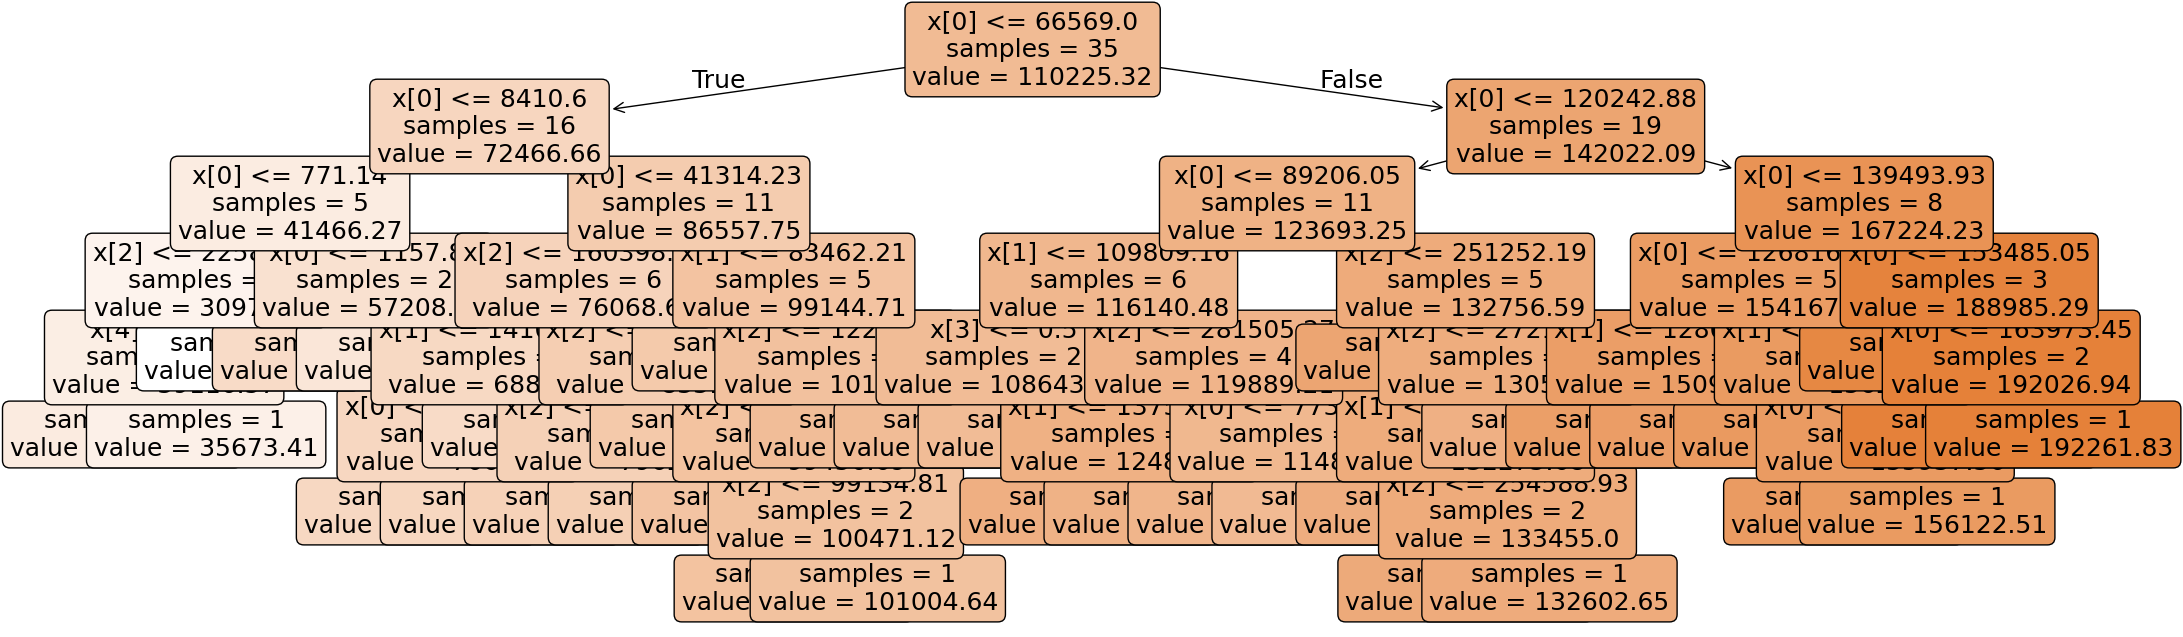

In [24]:
# create the model-decision-tree
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt
# Train the model
regr = DecisionTreeRegressor(random_state=42)
regr.fit(x_train, y_train)
# Visualize the decision tree
plt.figure(figsize=(26,8))
plot_tree(regr, filled=True, rounded=True, impurity=False, fontsize=18, precision=2)
plt.show()


In [26]:
from sklearn.metrics import r2_score

# 1. Define Parameter Grid
criterions = ['squared_error', 'friedman_mse', 'absolute_error', 'poisson']
splitters = ['best', 'random']
max_depths = [None, 5, 10, 20]
min_samples_splits = [2, 5, 10]
min_samples_leafs = [1, 2, 4]

# 2. Storage
dt_results = []

# 3. Manual Grid Search
for criterion in criterions:
    for splitter in splitters:
        for depth in max_depths:
            for min_split in min_samples_splits:
                for min_leaf in min_samples_leafs:

                    model = DecisionTreeRegressor(
                        criterion=criterion,
                        splitter=splitter,
                        max_depth=depth,
                        min_samples_split=min_split,
                        min_samples_leaf=min_leaf,
                        random_state=42
                    )

                    model.fit(x_train, y_train)
                    preds = model.predict(x_test)
                    r2 = r2_score(y_test, preds)

                    dt_results.append({
                        'criterion': criterion,
                        'splitter': splitter,
                        'max_depth': depth,
                        'min_samples_split': min_split,
                        'min_samples_leaf': min_leaf,
                        'r2_score': r2
                    })

# 4. Find Best Model
best_dt_model = max(dt_results, key=lambda x: x['r2_score'])

best_dt_model


{'criterion': 'absolute_error',
 'splitter': 'best',
 'max_depth': None,
 'min_samples_split': 2,
 'min_samples_leaf': 2,
 'r2_score': 0.9564860381659932}

In [32]:
df_results = pd.DataFrame(dt_results)
# Sort by R² descending
df_results_sorted = df_results.sort_values(by='r2_score', ascending=False)
df_results_sorted.head(10)   # show top 10 models

,criterion,splitter,max_depth,min_samples_split,min_samples_leaf,r2_score
172,absolute_error,best,20.0,2,2,0.956486
145,absolute_error,best,NaN,2,2,0.956486
154,absolute_error,best,5.0,2,2,0.956486
163,absolute_error,best,10.0,2,2,0.956486
174,absolute_error,best,20.0,5,1,0.950717
147,absolute_error,best,NaN,5,1,0.950717
156,absolute_error,best,5.0,5,1,0.950717
165,absolute_error,best,10.0,5,1,0.950717
144,absolute_error,best,NaN,2,1,0.946457
171,absolute_error,best,20.0,2,1,0.946457


In [38]:
"""
import pickle

best_model = DecisionTreeRegressor(
    criterion=best_dt_model['criterion'],
    splitter=best_dt_model['splitter'],
    max_depth=best_dt_model['max_depth'],
    min_samples_split=best_dt_model['min_samples_split'],
    min_samples_leaf=best_dt_model['min_samples_leaf'],
    random_state=42
)
best_model.fit(x_train, y_train)
with open('best_decision_tree_model.sav', 'wb') as f:
    pickle.dump(best_model, f)

print("Model saved successfully!")
"""


'\nimport pickle\n\nbest_model = DecisionTreeRegressor(\n    criterion=best_dt_model[\'criterion\'],\n    splitter=best_dt_model[\'splitter\'],\n    max_depth=best_dt_model[\'max_depth\'],\n    min_samples_split=best_dt_model[\'min_samples_split\'],\n    min_samples_leaf=best_dt_model[\'min_samples_leaf\'],\n    random_state=42\n)\nbest_model.fit(x_train, y_train)\nwith open(\'best_decision_tree_model.sav\', \'wb\') as f:\n    pickle.dump(best_model, f)\n\nprint("Model saved successfully!")\n'

In [37]:
import joblib
import json
from datetime import datetime

# Create model folder if not exists
import os
os.makedirs("models", exist_ok=True)

# File names
model_path = "models/decision_tree_v1.joblib"
metadata_path = "models/metadata_v1.json"

# Save model
joblib.dump(best_model, model_path)

# Save metadata
metadata = {
    "model_name": "DecisionTreeRegressor",
    "version": "v1",
    "trained_on": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "r2_score": best_dt_model["r2_score"],
    "hyperparameters": {
        "criterion": best_dt_model["criterion"],
        "splitter": best_dt_model["splitter"],
        "max_depth": best_dt_model["max_depth"],
        "min_samples_split": best_dt_model["min_samples_split"],
        "min_samples_leaf": best_dt_model["min_samples_leaf"]
    }
}

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print("Model and metadata saved successfully.")


Model and metadata saved successfully.
